<a href="https://colab.research.google.com/github/Rxjxt/machine-learning-lab-/blob/main/lab10_ann_and_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving ai4i2020.csv to ai4i2020.csv


In [4]:
import pandas as pd

df = pd.read_csv("ai4i2020.csv")   # ya read_excel

df.columns = df.columns.str.strip()

print(df.shape)

(10000, 14)


In [5]:
print(df.info())
print(df.describe())
print("Missing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
target_col = 'Machine failure'

print(df[target_col].value_counts())

Machine failure
0    9661
1     339
Name: count, dtype: int64


In [7]:
df = df.drop(['UDI'], axis=1)

In [8]:
df = pd.get_dummies(df, drop_first=True)

In [9]:
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101
)

In [12]:
# drop all Product ID columns
df = df.drop(columns=[col for col in df.columns if 'Product ID' in col])

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

X_scaled = scaler.fit_transform(X)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.30, random_state=101
)

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)

model.fit(X_train, y_train)

LogisticRegression(max_iter=500)

In [16]:
predictions = model.predict(X_test)

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Confusion Matrix:\n", confusion_matrix(y_test, predictions))

print("\nClassification Report:\n", classification_report(y_test, predictions))

print("\nAccuracy:", accuracy_score(y_test, predictions))

Confusion Matrix:
 [[2886    0]
 [   5  109]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2886
           1       1.00      0.96      0.98       114

    accuracy                           1.00      3000
   macro avg       1.00      0.98      0.99      3000
weighted avg       1.00      1.00      1.00      3000


Accuracy: 0.9983333333333333


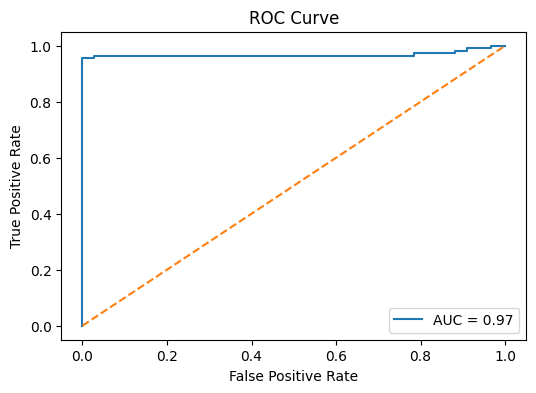

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.show()